In [1]:
import torch
import deepinv as dinv
from deepinv.models.wrapper import DiffusersDenoiserWrapper

device = dinv.utils.get_device()
dtype = torch.float32
figsize = 2.5

from deepinv.sampling import PosteriorDiffusion, EulerSolver, VariancePreservingDiffusion, VarianceExplodingDiffusion
from deepinv.optim import ZeroFidelity


/users/aspagnol/venvs/dinv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Selected GPU 0 with 80537.75 MiB free memory


In [18]:
# ----------------------------------------------------
#
# Let us first load a pretrained latent diffusion model from the HuggingFace Hub. Here, we use the `runwayml/stable-diffusion-v1-5` model.
# This model is trained on 512x512 images.

# We can wrap any diffusers model as a DeepInv denoiser using one line of code:
denoiser = DiffusersDenoiserWrapper(
    model_id="runwayml/stable-diffusion-v1-5", pipeline_name="DiffusionPipeline", device=device, clip_output=False,
)
from diffusers import DDIMScheduler
denoiser.scheduler = DDIMScheduler.from_config(denoiser.scheduler.config)

# Load an example image
x = dinv.utils.load_example(
    "celeba_example2.jpg",
    img_size=512,
    resize_mode="resize",
).to(device)

tokenizer = denoiser.tokenizer
text_encoder = denoiser.text_encoder

# Define the prompt
prompt = ["a high resolution photo of a cat on a grass field, 4K, sharp"]

# # Encode the prompt to conditioning embeddings
# text_inputs = tokenizer(
#     prompt, 
#     padding="max_length", 
#     max_length=tokenizer.model_max_length,
#     truncation=True,
#     return_tensors="pt"
# )

# # Empty prompt for unconditional guidance
# uncond_inputs = tokenizer(
#     [""] * len(prompt),
#     padding="max_length",
#     max_length=tokenizer.model_max_length,
#     truncation=True,
#     return_tensors="pt"
# )

# # Encode conditional prompt
# text_embeddings = text_encoder(text_inputs.input_ids.to(device))[0]


# # Encode unconditional prompt
# uncond_embeddings = text_encoder(uncond_inputs.input_ids.to(device))[0]

# # Concatenate unconditional and conditional embeddings for CFG
# text_embeddings_cfg = torch.cat([uncond_embeddings, text_embeddings], dim=0)


/users/aspagnol/venvs/dinv/lib/python3.10/site-packages/diffusers/utils/deprecation_utils.py:23: FutureWarning: `torch_dtype` is deprecated and will be removed in version 1.0.0. Please use `dtype` instead.
  deprecate("torch_dtype", "1.0.0", _TORCH_DTYPE_DEPRECATION_MESSAGE)
Loading pipeline components...: 100%|██████████| 7/7 [00:00<00:00,  9.10it/s]


100%|██████████| 199/199 [00:12<00:00, 16.28it/s]


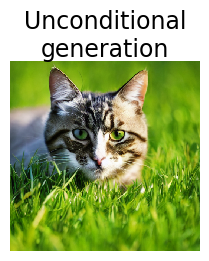

In [19]:
# ---------------------------------
#
# It is also possible to use the wrapped model for unconditional image generation.
# The model was trained with DDPM scheduler, however we can use it with any SDE provided in DeepInv.
# Here, we use the Variance Preserving SDE with Euler solver for sampling.

num_steps = 200
timesteps = torch.linspace(1, 0.001, num_steps)
rng = torch.Generator(device)
solver = EulerSolver(timesteps=timesteps, rng=rng)

sde = VariancePreservingDiffusion(
    beta_min=0.85,
    beta_max=12.0,
    scaled_linear=True,
    device=device,
    dtype=dtype,
    alpha=0.5,
)

model = PosteriorDiffusion(
    data_fidelity=ZeroFidelity(),
    sde=sde,
    denoiser=denoiser,
    solver=solver,
    dtype=dtype,
    device=device,
    verbose=True,
    minus_one_one=False,
)

z = torch.randn(
    1, 4, 64, 64,
    device=device,
    dtype=dtype,
)

sample, trajectory = model(
    y=None,
    physics=None,
    x_init=z,
    seed=42,
    get_trajectory=True,
    prompt=prompt,
    input_in_minus_one_one=True,   # important
    denoise_output=False,
    guidance_scale = 6,
)
dinv.utils.plot(
    sample,
    titles="Unconditional generation",
    figsize=(figsize, figsize),
)


In [11]:
# ---------------------
#
# Similar to other denoisers in DeepInv, the wrapped diffusers model can be used for posterior sampling.
# Below we use the same VP-SDE for posterior sampling in an inpainting problem.

# Initialize the physics

mask = torch.ones_like(x)
mask[..., 128:384, 128:384] = 0
physics = dinv.physics.Inpainting(
    mask=mask,
    img_size=x.shape[1:],
    device=device,
    noise_model=dinv.physics.GaussianNoise(0.01),
)

# ksize = 3
# physics = dinv.physics.BlurFFT(
#     img_size=x.shape[1:],
#     filter=dinv.physics.blur.gaussian_blur(sigma=(ksize, ksize)),
#     device=device,
#     noise_model=dinv.physics.GaussianNoise(0.01),
# )

y = physics(x)


In [12]:

from deepinv.sampling import DPSDataFidelity

num_steps = 500
timesteps = torch.linspace(1, 0.001, num_steps)
rng = torch.Generator(device)
solver = EulerSolver(timesteps=timesteps, rng=rng)

sde = VariancePreservingDiffusion(
    beta_min=0.85,
    beta_max=12.0,
    scaled_linear=True,
    device=device,
    dtype=dtype,
    alpha=0.5,
)

model = PosteriorDiffusion(
    data_fidelity=DPSDataFidelity(denoiser=denoiser, sde=sde, timesteps=timesteps, original_algo=True, weight=1.0),
    denoiser=denoiser,
    sde=sde,
    solver=solver,
    dtype=dtype,
    device=device,
    verbose=True,
    minus_one_one=False,
)


100%|██████████| 499/499 [02:05<00:00,  3.97it/s]


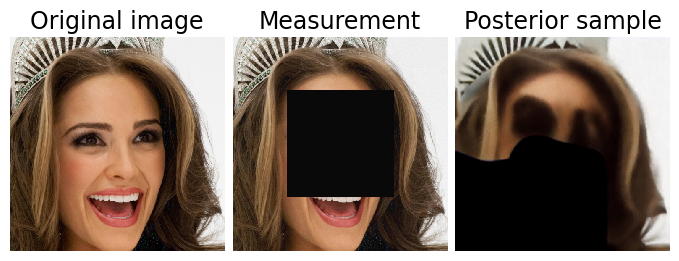

In [13]:
# Define the prompt
prompt = [""]

z = torch.randn(
    1, 4, 64, 64,
    device=device,
    dtype=dtype,
)

posterior_sample = model(
    y=y,
    physics=physics,
    x_init=z,
    seed=15,
    prompt=prompt,
    input_in_minus_one_one=True,   # important
    denoise_output=False,
    guidance_scale = 1,
)
dinv.utils.plot(
    [x, y, posterior_sample],
    titles=["Original image", "Measurement", "Posterior sample"],
    figsize=(figsize * 3, figsize),
)


In [16]:
from deepinv.sampling import PSLDDataFidelity

num_steps = 500
timesteps = torch.linspace(1, 0.001, num_steps)
rng = torch.Generator(device)
solver = EulerSolver(timesteps=timesteps, rng=rng)

sde = VariancePreservingDiffusion(
    beta_min=0.85,
    beta_max=12.0,
    scaled_linear=True,
    device=device,
    dtype=dtype,
    alpha=0.5,
)

model = PosteriorDiffusion(
    data_fidelity=PSLDDataFidelity(denoiser=denoiser, sde=sde, timesteps=timesteps, omega=1.0, gamma=0.1),
    denoiser=denoiser,
    sde=sde,
    solver=solver,
    dtype=dtype,
    device=device,
    verbose=True,
    minus_one_one=False,
)


100%|██████████| 499/499 [02:27<00:00,  3.38it/s]


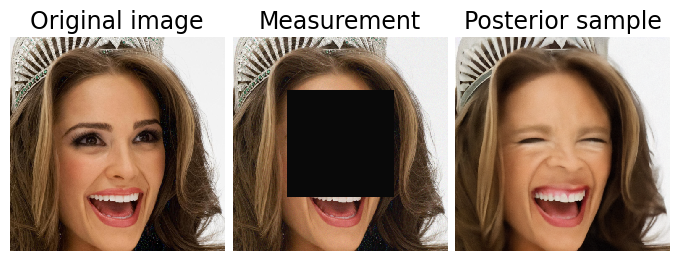

In [17]:
# Define the prompt
prompt = [""]

z = torch.randn(
    1, 4, 64, 64,
    device=device,
    dtype=dtype,
)

posterior_sample = model(
    y=y,
    physics=physics,
    x_init=z,
    seed=15,
    prompt=prompt,
    input_in_minus_one_one=True,   # important
    denoise_output=False,
    guidance_scale = 1,
)
dinv.utils.plot(
    [x, y, posterior_sample],
    titles=["Original image", "Measurement", "Posterior sample"],
    figsize=(figsize * 3, figsize),
)